# 01: 50ETF 及期权数据描述性统计

本 notebook 对 50ETF 现货及其期权数据进行描述性统计与可视化，为后续策略回测提供数据基础。

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')
sns.set_palette('Set2')
from src.utils.visualize import plot_vol_cone, setup_chinese_font
setup_chinese_font()

from src.data.preprocess import prepare_etf_daily, prepare_options_daily_with_greeks
from src.models.vol_cone import build_vol_cone

SAVE_DIR = '../Data/processed/'
print('Imports OK')

## 1. 50ETF 价格概览 (2010–2025)

In [2]:
# 加载全周期 ETF 日线数据
etf_full = prepare_etf_daily(start_date='2010-01-01', end_date='2025-12-31')
print(f'ETF 日线数据: {etf_full.shape[0]} 个交易日')
print(f'时间范围: {etf_full.index.min().date()} ~ {etf_full.index.max().date()}')
print(f'价格范围: {etf_full["close"].min():.3f} ~ {etf_full["close"].max():.3f}')
print(f'年均波动率: {etf_full["log_return"].std() * np.sqrt(252) * 100:.2f}%')
etf_full.head()

ETF 日线数据: 3885 个交易日
时间范围: 2010-01-04 ~ 2025-12-31
价格范围: 1.408 ~ 4.014
年均波动率: 22.10%


,open,high,low,close,volume,amount,log_return
date,,,,,,,
2010-01-04,2.569,2.572,2.511,2.512,7.864332e+08,2.000121e+09,NaN
2010-01-05,2.525,2.561,2.489,2.544,1.099879e+09,2.781187e+09,0.012658
2010-01-06,2.539,2.550,2.511,2.512,5.465725e+08,1.384265e+09,-0.012658
2010-01-07,2.513,2.526,2.450,2.462,8.942675e+08,2.226035e+09,-0.020105
2010-01-08,2.458,2.468,2.427,2.462,8.854760e+08,2.168222e+09,0.000000


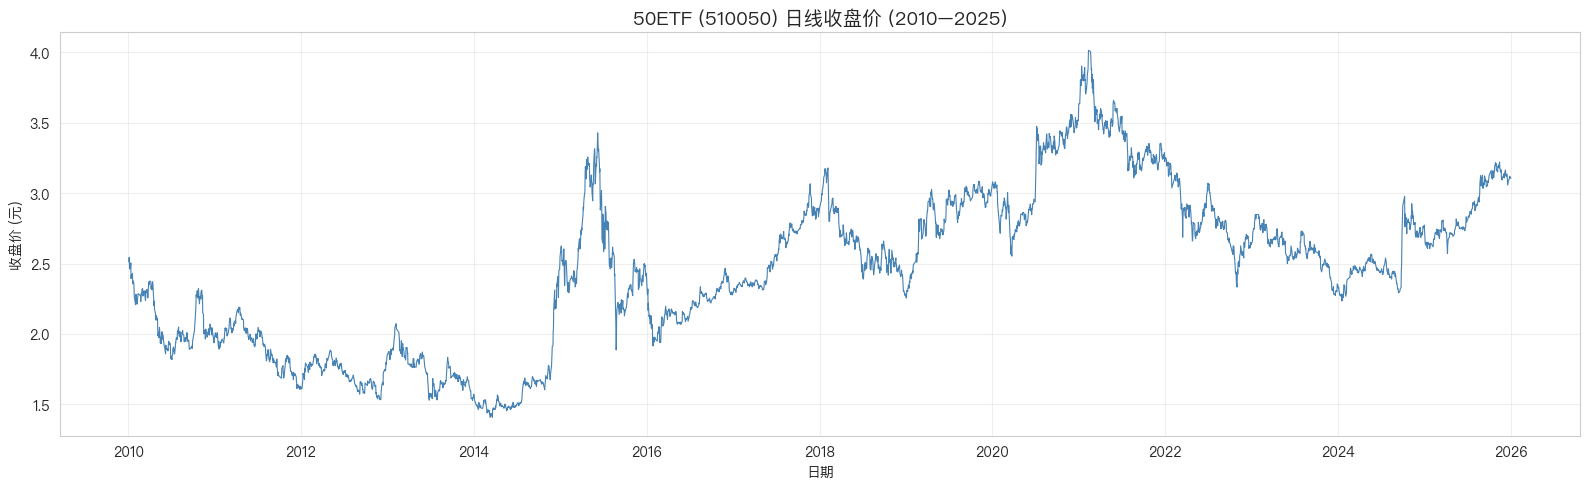

In [3]:
# 50ETF 收盘价走势
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(etf_full.index, etf_full['close'], linewidth=0.8, color='steelblue')
ax.set_title('50ETF (510050) 日线收盘价 (2010–2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('收盘价 (元)')
ax.set_xlabel('日期')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_etf_price.png', dpi=150, bbox_inches='tight')
plt.show()

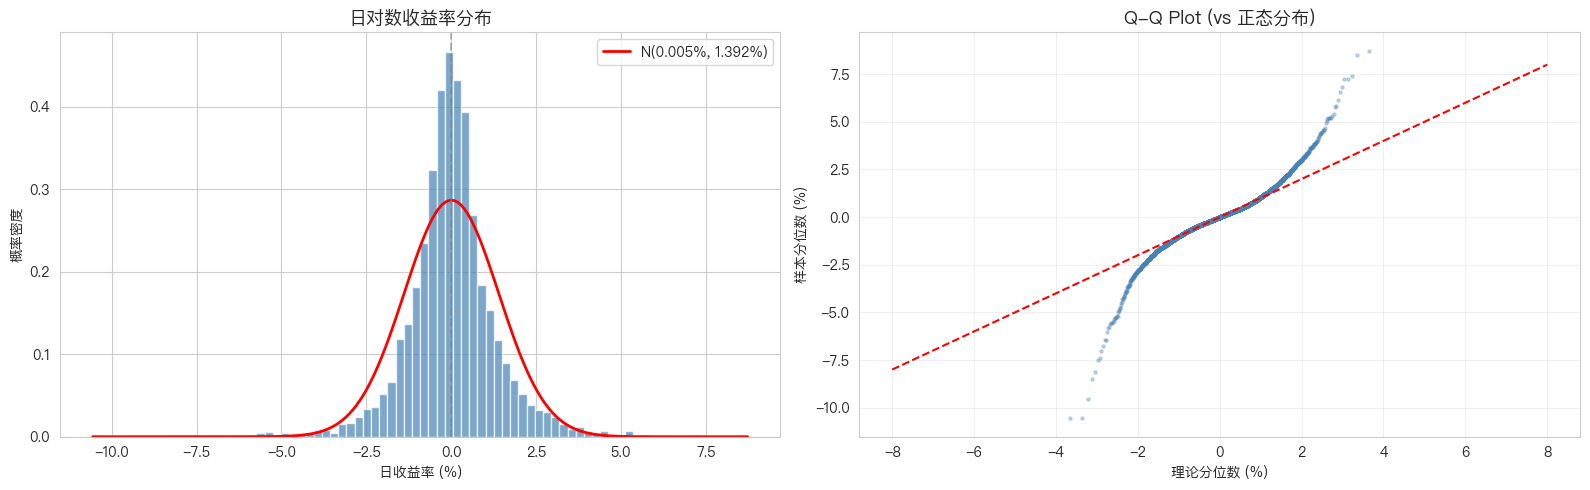

日收益率统计:
  均值: 0.0055%
  标准差: 1.3920%
  偏度: -0.2733
  峰度: 6.7985
  Jarque-Bera: 7528.19 (p=0.00e+00)
  最大单日涨幅: 8.73%
  最大单日跌幅: -10.56%


In [4]:
# 日对数收益率分布
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

log_ret = etf_full['log_return'].dropna()
axes[0].hist(log_ret * 100, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x = np.linspace(log_ret.min(), log_ret.max(), 200) * 100
mu, sigma = log_ret.mean() * 100, log_ret.std() * 100
axes[0].plot(x, 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*((x-mu)/sigma)**2),
           'r-', linewidth=2, label=f'N({mu:.3f}%, {sigma:.3f}%)')
axes[0].set_title('日对数收益率分布', fontsize=13, fontweight='bold')
axes[0].set_xlabel('日收益率 (%)')
axes[0].set_ylabel('概率密度')
axes[0].legend()
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# QQ plot
from scipy import stats
axes[1].scatter(stats.norm.ppf((np.arange(len(log_ret))+0.5)/len(log_ret)),
              np.sort(log_ret)*100, alpha=0.3, s=5, color='steelblue')
axes[1].plot([-8, 8], [-8, 8], 'r--', linewidth=1.5)
axes[1].set_title('Q-Q Plot (vs 正态分布)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('理论分位数 (%)')
axes[1].set_ylabel('样本分位数 (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '01_returns_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
from scipy.stats import skew, kurtosis, jarque_bera
print(f'日收益率统计:')
print(f'  均值: {log_ret.mean()*100:.4f}%')
print(f'  标准差: {log_ret.std()*100:.4f}%')
print(f'  偏度: {skew(log_ret):.4f}')
print(f'  峰度: {kurtosis(log_ret):.4f}')
jb_stat, jb_p = jarque_bera(log_ret)
print(f'  Jarque-Bera: {jb_stat:.2f} (p={jb_p:.2e})')
print(f'  最大单日涨幅: {log_ret.max()*100:.2f}%')
print(f'  最大单日跌幅: {log_ret.min()*100:.2f}%')

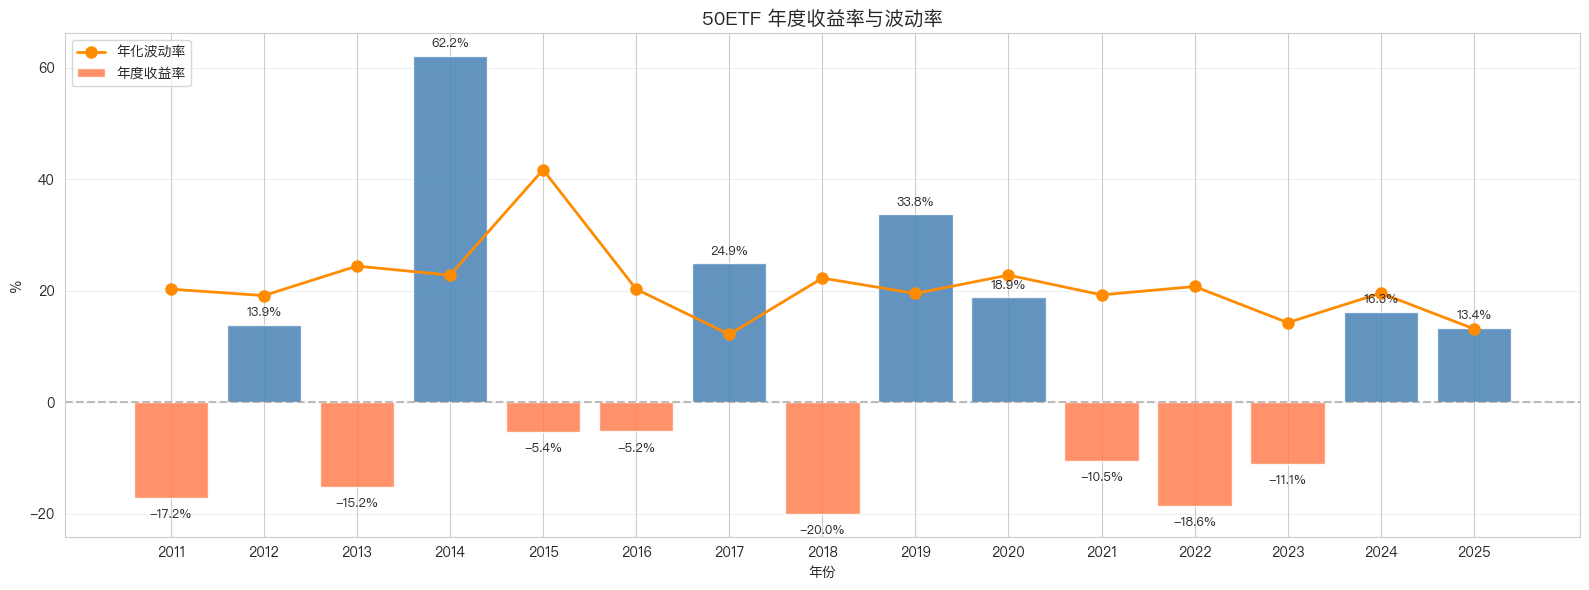

      收益率(%)  波动率(%)
date                
2011  -17.23   20.31
2012   13.87   19.15
2013  -15.20   24.45
2014   62.17   22.82
2015   -5.37   41.73
2016   -5.22   20.31
2017   24.91   12.19
2018  -20.01   22.29
2019   33.77   19.53
2020   18.87   22.82
2021  -10.48   19.28
2022  -18.59   20.78
2023  -11.10   14.30
2024   16.26   19.60
2025   13.40   13.19


In [5]:
# 年度收益率柱状图
annual = etf_full['close'].resample('YE').last()
annual_ret = annual.pct_change().dropna() * 100
annual_vol = etf_full['log_return'].resample('YE').std().loc[annual_ret.index] * np.sqrt(252) * 100
annual_stats = pd.DataFrame({'收益率(%)': annual_ret.values, '波动率(%)': annual_vol.values},
                           index=annual_ret.index.year)

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['coral' if v < 0 else 'steelblue' for v in annual_stats['收益率(%)']]
bars = ax.bar(annual_stats.index.astype(str), annual_stats['收益率(%)'], color=colors, alpha=0.85, label='年度收益率')
ax.plot(range(len(annual_stats)), annual_stats['波动率(%)'], 'o-', color='darkorange', linewidth=2, markersize=8, label='年化波动率')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('50ETF 年度收益率与波动率', fontsize=14, fontweight='bold')
ax.set_xlabel('年份')
ax.set_ylabel('%')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, annual_stats['收益率(%)']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (1 if val>0 else -2),
            f'{val:.1f}%', ha='center', va='bottom' if val>0 else 'top', fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print(annual_stats.round(2).to_string())

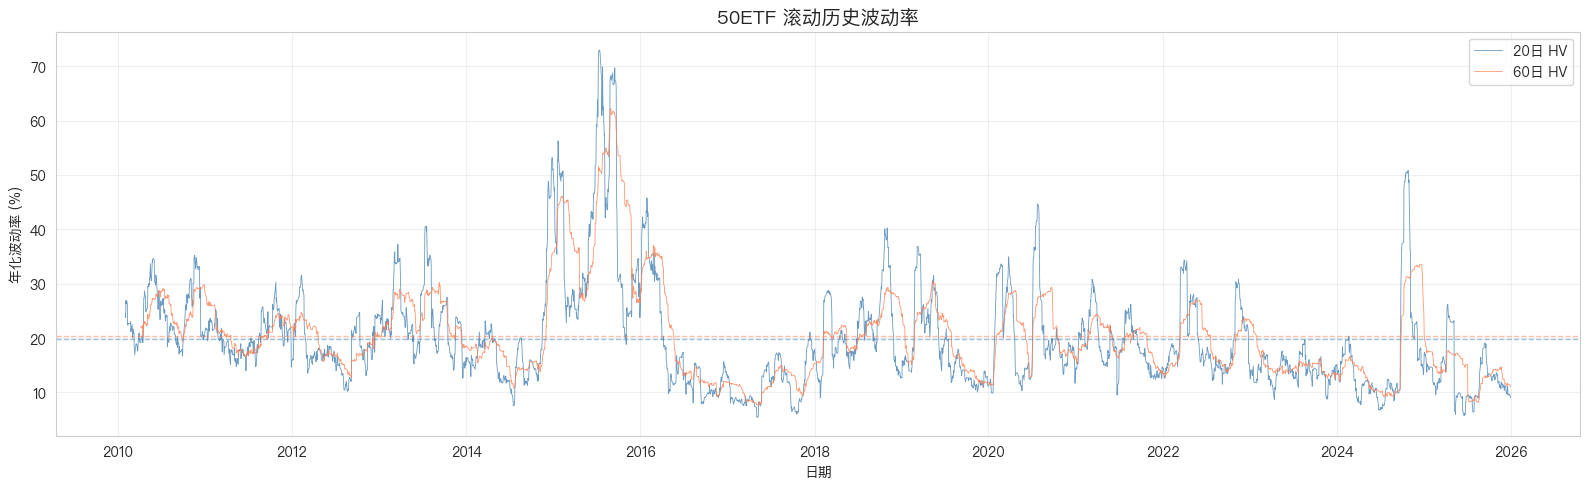

20日 HV 均值: 19.8%, 区间: [5.4%, 73.0%]
60日 HV 均值: 20.5%, 区间: [7.6%, 62.3%]


In [6]:
# 滚动历史波动率 (20日 / 60日)
hv20 = etf_full['log_return'].rolling(20).std() * np.sqrt(252) * 100
hv60 = etf_full['log_return'].rolling(60).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(etf_full.index, hv20, linewidth=0.6, alpha=0.8, label='20日 HV', color='steelblue')
ax.plot(etf_full.index, hv60, linewidth=0.6, alpha=0.8, label='60日 HV', color='coral')
ax.axhline(y=hv20.mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=hv60.mean(), color='coral', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('50ETF 滚动历史波动率', fontsize=14, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('年化波动率 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_rolling_vol.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'20日 HV 均值: {hv20.mean():.1f}%, 区间: [{hv20.min():.1f}%, {hv20.max():.1f}%]')
print(f'60日 HV 均值: {hv60.mean():.1f}%, 区间: [{hv60.min():.1f}%, {hv60.max():.1f}%]')

## 2. 期权数据概览 (2015–2025)

In [7]:
# 加载期权数据（带 Greeks）
opts_c = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='C')
opts_p = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='P')

opts_c['year'] = opts_c['date'].dt.year
opts_p['year'] = opts_p['date'].dt.year
all_opts = pd.concat([opts_c, opts_p], ignore_index=True)

print(f'Call 期权: {opts_c["code"].nunique()} 个合约, {len(opts_c):,} 条日线记录')
print(f'Put  期权: {opts_p["code"].nunique()} 个合约, {len(opts_p):,} 条日线记录')
print(f'合计: {all_opts["code"].nunique()} 个合约, {len(all_opts):,} 条日线记录')
print(f'IV 范围 (Call): [{opts_c["iv"].min():.4f}, {opts_c["iv"].max():.4f}]')
print(f'IV 范围 (Put):  [{opts_p["iv"].min():.4f}, {opts_p["iv"].max():.4f}]')
print(f'到期月份数: {opts_c["EXPIRY_DATE"].nunique()}')
print(f'执行价格数: {opts_c["EXERCISE_PRICE"].nunique()}')

Call 期权: 3400 个合约, 229,074 条日线记录
Put  期权: 3403 个合约, 226,877 条日线记录
合计: 6803 个合约, 455,951 条日线记录
IV 范围 (Call): [0.0010, 3.3356]
IV 范围 (Put):  [0.0010, 5.0000]
到期月份数: 134
执行价格数: 246


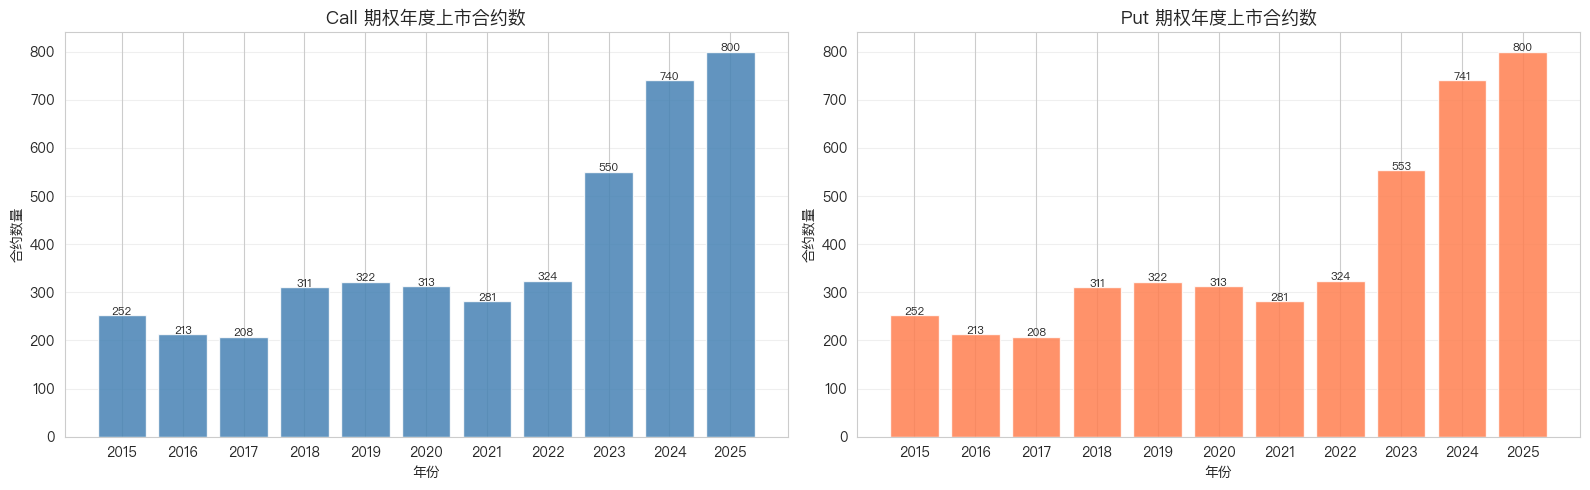

In [8]:
# 各年度上市合约数量
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

c_by_year = opts_c.groupby('year')['code'].nunique()
axes[0].bar(c_by_year.index.astype(str), c_by_year.values, color='steelblue', alpha=0.85)
axes[0].set_title('Call 期权年度上市合约数', fontsize=13, fontweight='bold')
axes[0].set_xlabel('年份')
axes[0].set_ylabel('合约数量')
axes[0].grid(True, alpha=0.3, axis='y')
for x, y in zip(range(len(c_by_year)), c_by_year.values):
    axes[0].text(x, y + 1, str(y), ha='center', fontsize=8)

p_by_year = opts_p.groupby('year')['code'].nunique()
axes[1].bar(p_by_year.index.astype(str), p_by_year.values, color='coral', alpha=0.85)
axes[1].set_title('Put 期权年度上市合约数', fontsize=13, fontweight='bold')
axes[1].set_xlabel('年份')
axes[1].set_ylabel('合约数量')
axes[1].grid(True, alpha=0.3, axis='y')
for x, y in zip(range(len(p_by_year)), p_by_year.values):
    axes[1].text(x, y + 1, str(y), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR + '01_contracts_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

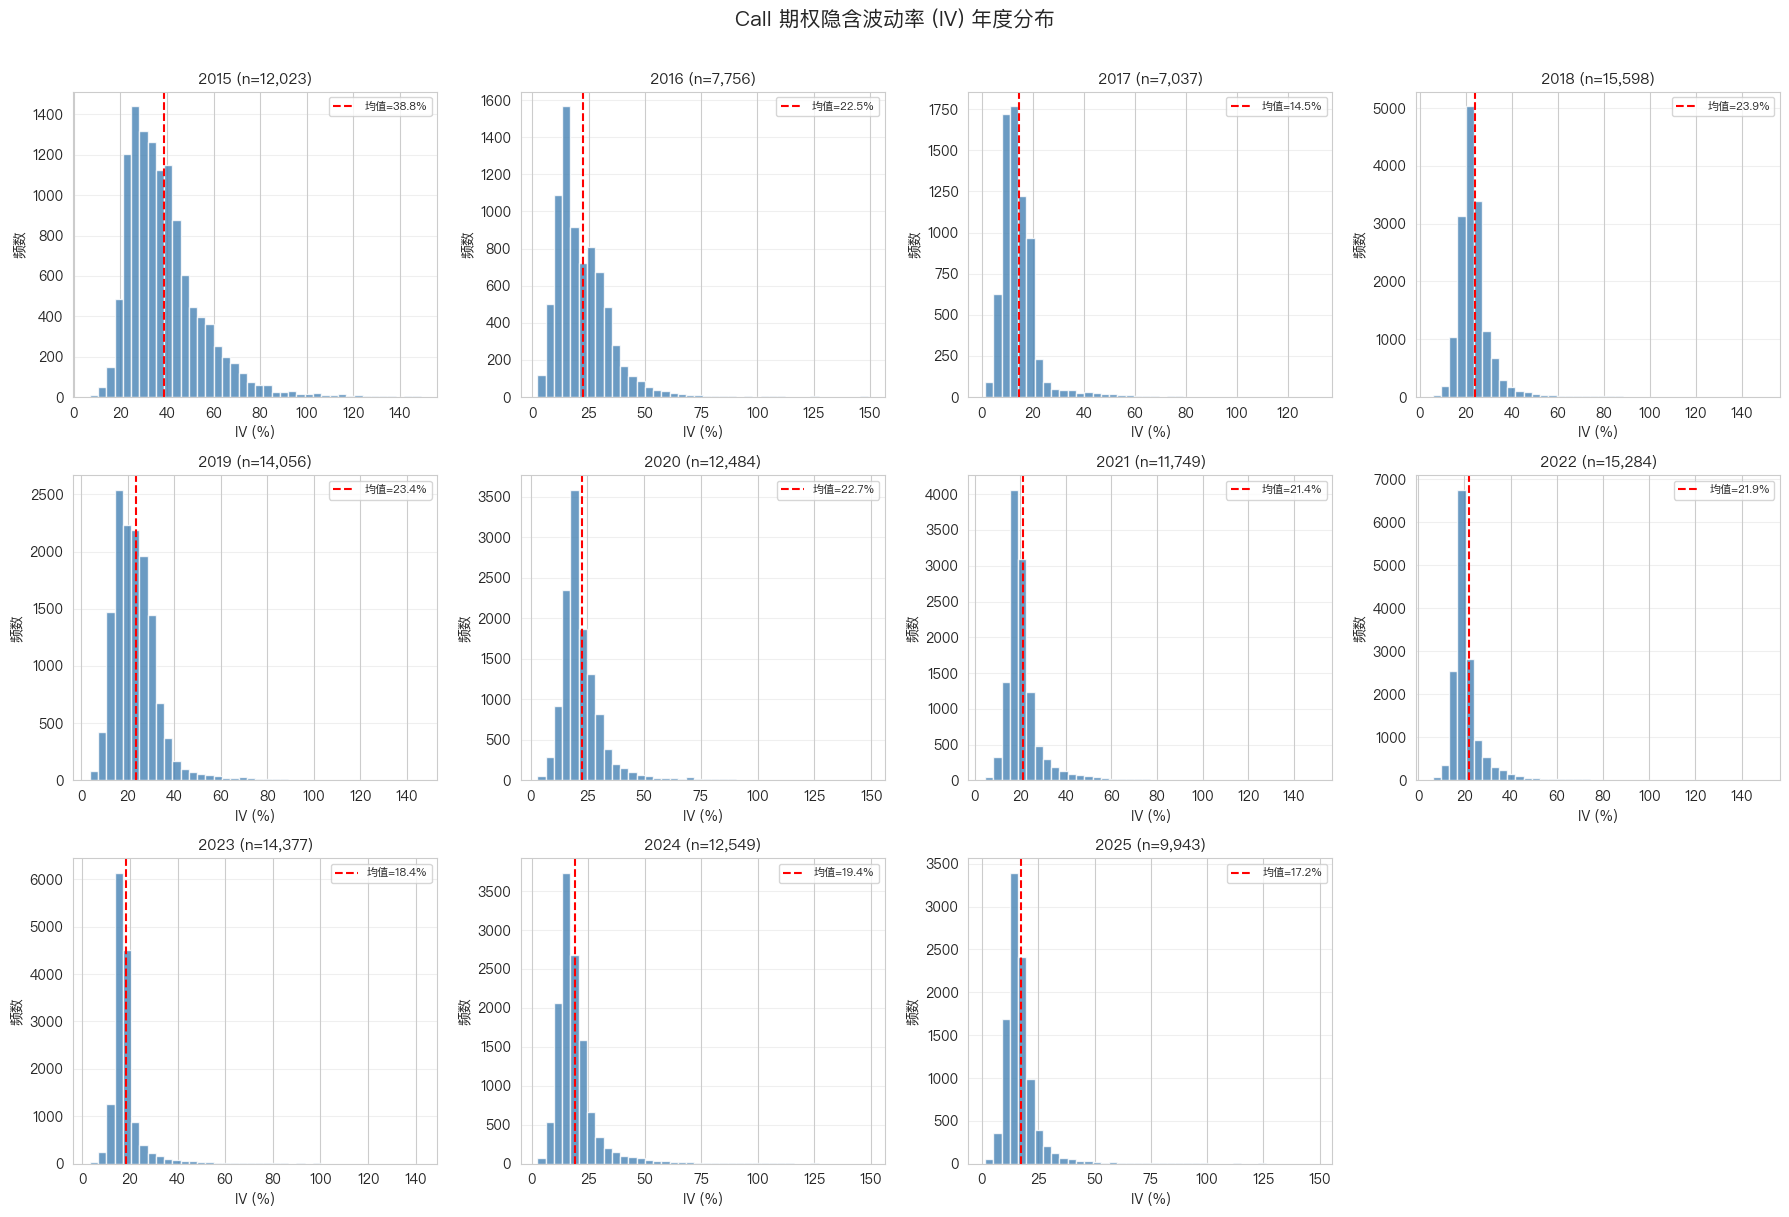

In [9]:
# IV 分布直方图 (Call, 按年度)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
years = sorted(opts_c['year'].unique())
axes = axes.flatten()

for i, yr in enumerate(years):
    ax = axes[i]
    iv_data = opts_c[opts_c['year'] == yr]['iv'].dropna()
    iv_data = iv_data[(iv_data > 0.01) & (iv_data < 1.5)]
    ax.hist(iv_data * 100, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(x=iv_data.mean()*100, color='red', linestyle='--', linewidth=1.5, label=f'均值={iv_data.mean()*100:.1f}%')
    ax.set_title(f'{yr} (n={len(iv_data):,})', fontsize=11)
    ax.set_xlabel('IV (%)')
    ax.set_ylabel('频数')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

for j in range(len(years), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Call 期权隐含波动率 (IV) 年度分布', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_iv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

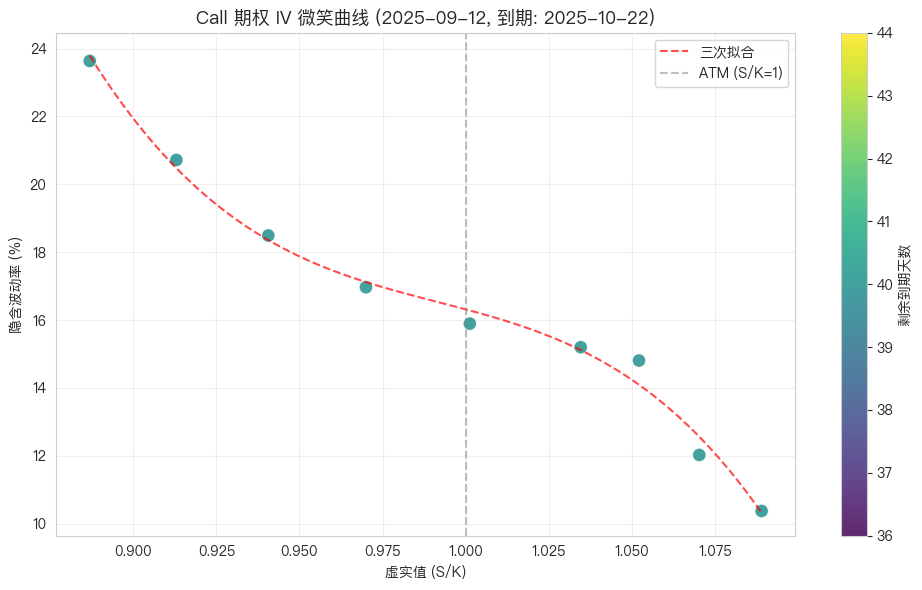

快照日期: 2025-09-12, 到期日: 2025-10-22, 剩余 40 天
合约数: 9, 虚实值范围: [0.89, 1.09]
IV 范围: [10.4%, 23.6%]


In [10]:
# IV 微笑 / 偏斜 — 选一个流动性好的近月到期日
# 找 ETF 数据范围内的、合约数量最多的到期日
expiries_in_range = [e for e in sorted(opts_c['EXPIRY_DATE'].unique()) if e <= pd.Timestamp('2025-12-31')]
# 取倒数第3个到期月（避免最后一个可能数据不全）
target_expiry = expiries_in_range[-3]
expiry_data = opts_c[opts_c['EXPIRY_DATE'] == target_expiry].copy()
expiry_data['moneyness'] = expiry_data['etf_price'] / expiry_data['EXERCISE_PRICE']

# 选到期前30天左右的日期，此时合约流动性好、IV 有意义
dates = sorted(expiry_data['date'].unique())
# 找到距离到期约 20-40 天的日期
target_date = None
for d in dates:
    ttd = (target_expiry - d).days
    if 20 <= ttd <= 40:
        target_date = d
        break
if target_date is None:
    target_date = dates[len(dates)//2]  # fallback

snapshot = expiry_data[expiry_data['date'] == target_date].copy()
snapshot = snapshot[(snapshot['iv'] > 0.01) & (snapshot['iv'] < 2.0)]  # 过滤异常 IV

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(snapshot['moneyness'], snapshot['iv'] * 100,
               c=snapshot['T']*365.25, cmap='viridis', s=100, alpha=0.85, edgecolors='white')
# 添加拟合曲线
if len(snapshot) >= 4:
    z = np.polyfit(snapshot['moneyness'], snapshot['iv']*100, 3)
    x_smooth = np.linspace(snapshot['moneyness'].min(), snapshot['moneyness'].max(), 100)
    ax.plot(x_smooth, np.polyval(z, x_smooth), 'r--', linewidth=1.5, alpha=0.7, label='三次拟合')
ax.set_title(f'Call 期权 IV 微笑曲线 ({target_date.date()}, 到期: {target_expiry.date()})', fontsize=13, fontweight='bold')
ax.set_xlabel('虚实值 (S/K)')
ax.set_ylabel('隐含波动率 (%)')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='ATM (S/K=1)')
ax.legend()
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('剩余到期天数')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_iv_smile.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'快照日期: {target_date.date()}, 到期日: {target_expiry.date()}, 剩余 {int(snapshot["T"].mean()*365.25)} 天')
print(f'合约数: {len(snapshot)}, 虚实值范围: [{snapshot["moneyness"].min():.2f}, {snapshot["moneyness"].max():.2f}]')
print(f'IV 范围: [{snapshot["iv"].min()*100:.1f}%, {snapshot["iv"].max()*100:.1f}%]')

最佳交易日: 2015-02-09, 活跃到期月数: 4


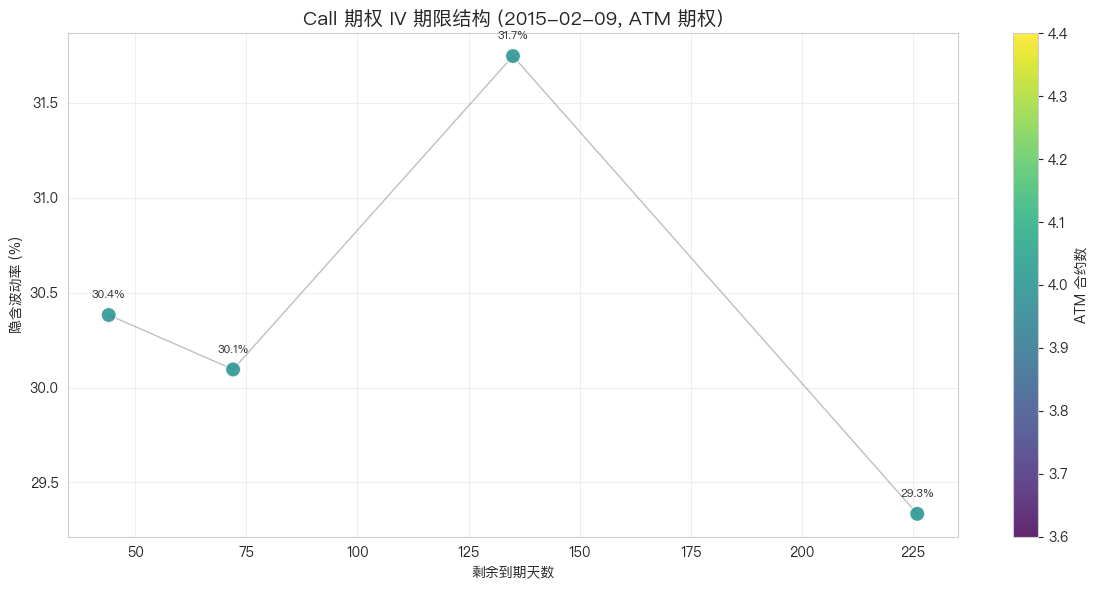

交易日: 2015-02-09, 活跃到期月: 4 个
ATM 合约总数: 16
   avg_t   avg_iv  count
0.120465 0.303824      4
0.197125 0.300957      4
0.369610 0.317467      4
0.618754 0.293348      4


In [11]:
# IV 期限结构 — 找同时有多个到期月存续的交易日
# 统计每个交易日有多少个活跃到期月
date_expiry_counts = opts_c.groupby('date')['EXPIRY_DATE'].nunique()
# 选到期月最多的交易日
best_date = date_expiry_counts.idxmax()
print(f'最佳交易日: {best_date.date()}, 活跃到期月数: {date_expiry_counts.max()}')

rep_data = opts_c[opts_c['date'] == best_date].copy()
rep_data = rep_data[rep_data['iv'].between(0.01, 2.0)]  # 过滤异常 IV
rep_data['moneyness'] = rep_data['etf_price'] / rep_data['EXERCISE_PRICE']
# ATM 附近 (S/K 在 0.95~1.05)
atm_data = rep_data[(rep_data['moneyness'] > 0.95) & (rep_data['moneyness'] < 1.05)].copy()
atm_data = atm_data.sort_values('T')

fig, ax = plt.subplots(figsize=(12, 6))

# 按到期月分组，每个到期月取平均 IV 画点
expiry_iv = atm_data.groupby('EXPIRY_DATE').agg(
    avg_iv=('iv', 'mean'),
    avg_t=('T', 'mean'),
    count=('code', 'count')
).reset_index()
expiry_iv = expiry_iv.sort_values('avg_t')

# 画散点 + 连线
sc = ax.scatter(expiry_iv['avg_t']*365.25, expiry_iv['avg_iv']*100,
               c=expiry_iv['count'], cmap='viridis', s=120, alpha=0.85, edgecolors='white', zorder=5)
ax.plot(expiry_iv['avg_t']*365.25, expiry_iv['avg_iv']*100, 'gray', linewidth=1, alpha=0.5)
# 标注数据点
for _, row in expiry_iv.iterrows():
    ax.annotate(f'{row["avg_iv"]*100:.1f}%', 
                (row['avg_t']*365.25, row['avg_iv']*100),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=8)

ax.set_title(f'Call 期权 IV 期限结构 ({best_date.date()}, ATM 期权)', fontsize=14, fontweight='bold')
ax.set_xlabel('剩余到期天数')
ax.set_ylabel('隐含波动率 (%)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('ATM 合约数')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_iv_term_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'交易日: {best_date.date()}, 活跃到期月: {date_expiry_counts.max()} 个')
print(f'ATM 合约总数: {len(atm_data)}')
print(expiry_iv[['avg_t', 'avg_iv', 'count']].to_string(index=False))

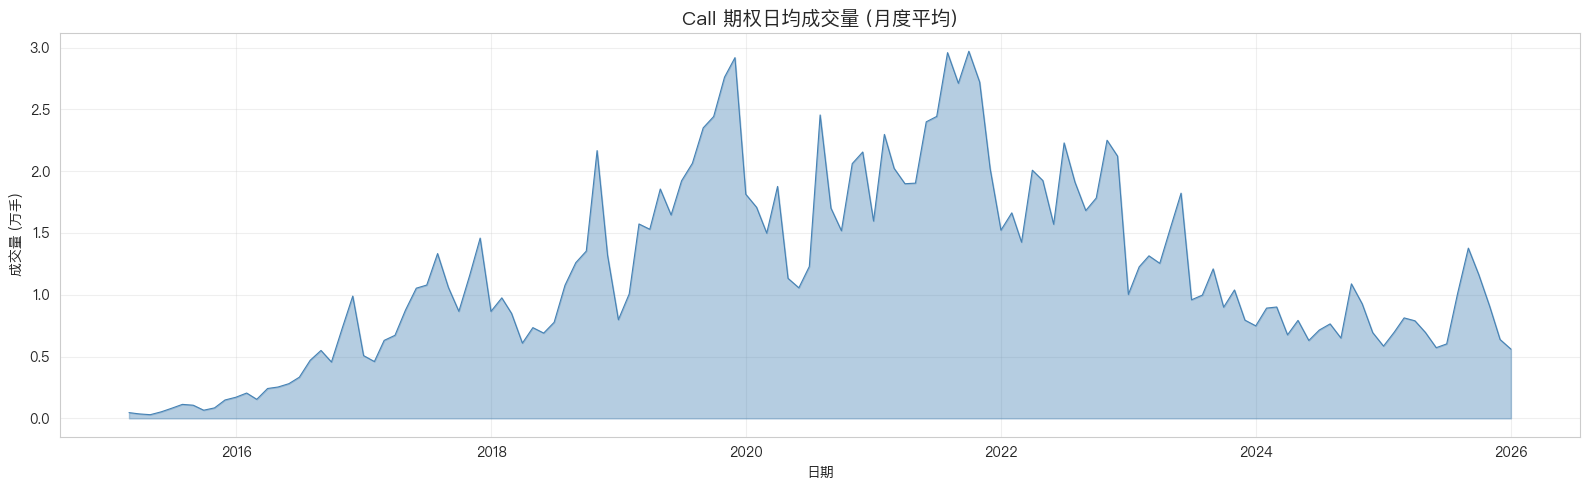

Call 期权日均成交量: 1.1 万手
Call 期权最大日成交量: 82.7 万手


In [12]:
# Call 期权日均成交量时序 (按月聚合)
monthly_vol = opts_c.set_index('date')['volume'].resample('ME').mean() / 10000

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(monthly_vol.index, monthly_vol.values, alpha=0.4, color='steelblue')
ax.plot(monthly_vol.index, monthly_vol.values, linewidth=0.8, color='steelblue')
ax.set_title('Call 期权日均成交量 (月度平均)', fontsize=14, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('成交量 (万手)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_option_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Call 期权日均成交量: {opts_c["volume"].mean()/10000:.1f} 万手')
print(f'Call 期权最大日成交量: {opts_c["volume"].max()/10000:.1f} 万手')

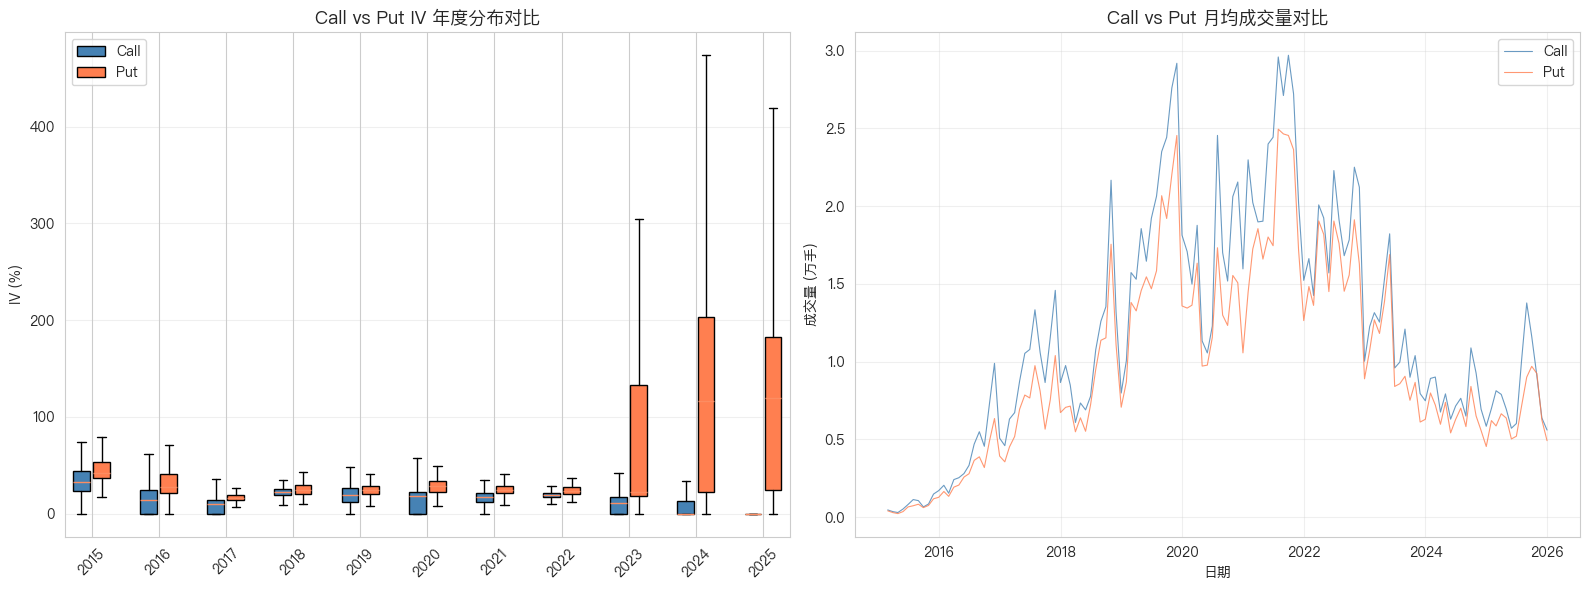

In [13]:
# Call vs Put IV 和成交量对比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

years_sorted = sorted(opts_c['year'].unique())
call_iv_by_year = [opts_c[opts_c['year']==y]['iv'].dropna()*100 for y in years_sorted]
put_iv_by_year = [opts_p[opts_p['year']==y]['iv'].dropna()*100 for y in years_sorted]

bp1 = axes[0].boxplot(call_iv_by_year, positions=np.arange(len(years_sorted))*2-0.3, widths=0.5,
                      patch_artist=True, showfliers=False)
bp2 = axes[0].boxplot(put_iv_by_year, positions=np.arange(len(years_sorted))*2+0.3, widths=0.5,
                      patch_artist=True, showfliers=False)
for patch in bp1['boxes']: patch.set_facecolor('steelblue')
for patch in bp2['boxes']: patch.set_facecolor('coral')
axes[0].set_xticks(np.arange(len(years_sorted))*2)
axes[0].set_xticklabels([str(y) for y in years_sorted], rotation=45)
axes[0].set_title('Call vs Put IV 年度分布对比', fontsize=13, fontweight='bold')
axes[0].set_ylabel('IV (%)')
axes[0].legend([bp1['boxes'][0], bp2['boxes'][0]], ['Call', 'Put'])
axes[0].grid(True, alpha=0.3, axis='y')

c_vol_m = opts_c.set_index('date')['volume'].resample('ME').mean() / 10000
p_vol_m = opts_p.set_index('date')['volume'].resample('ME').mean() / 10000
axes[1].plot(c_vol_m.index, c_vol_m.values, linewidth=0.8, color='steelblue', label='Call', alpha=0.8)
axes[1].plot(p_vol_m.index, p_vol_m.values, linewidth=0.8, color='coral', label='Put', alpha=0.8)
axes[1].set_title('Call vs Put 月均成交量对比', fontsize=13, fontweight='bold')
axes[1].set_xlabel('日期')
axes[1].set_ylabel('成交量 (万手)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '01_call_vs_put.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 实际波动率 (RV) vs 隐含波动率 (IV)

波动率套利的核心逻辑是赚取 IV 与 RV 之间的价差。下图对比 50ETF 20 日已实现波动率与 Call 期权日均隐含波动率。

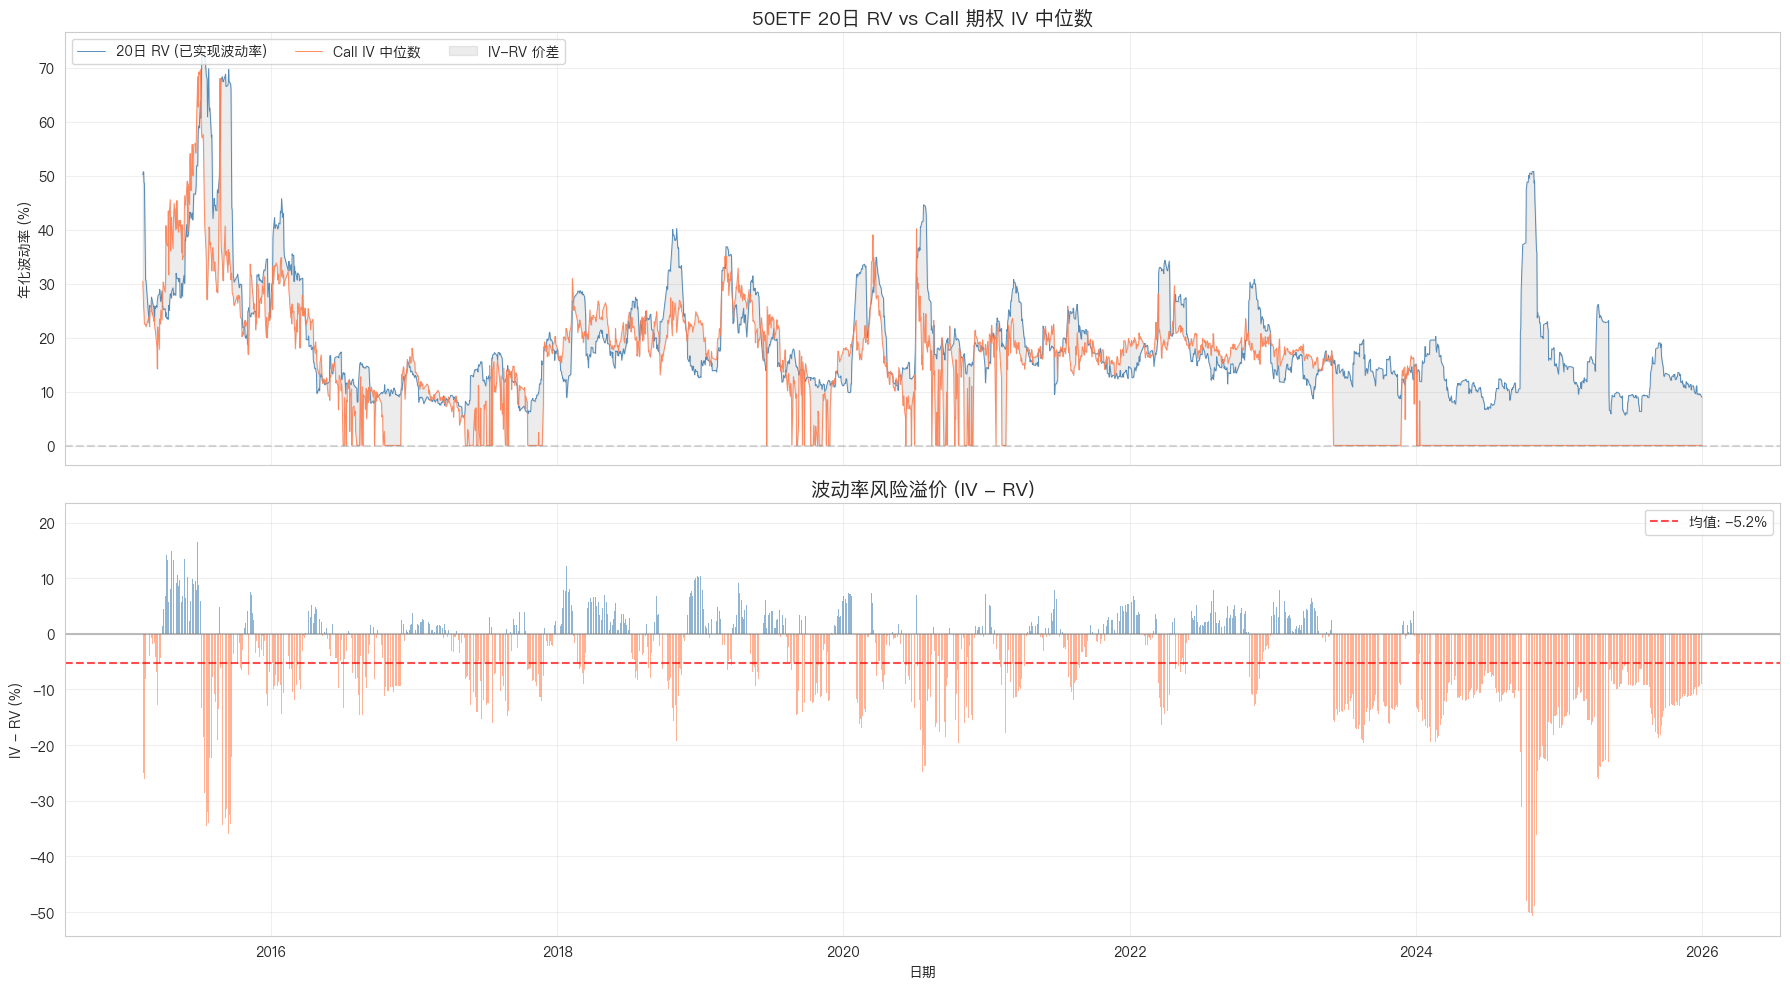

=== RV vs IV 统计 ===
20日 RV 均值: 19.0%
Call IV 中位数 均值: 13.9%
IV-RV 价差均值: -5.2%
IV-RV 价差中位数: -4.0%
IV > RV 的天数占比: 35.6%
IV < RV 的天数占比: 64.4%

年度 IV-RV 价差均值:
  2015: -4.6%
  2016: -4.3%
  2017: -3.4%
  2018: +0.1%
  2019: -1.1%
  2020: -6.1%
  2021: -1.7%
  2022: -1.1%
  2023: -5.7%
  2024: -16.1%
  2025: -12.6%


In [14]:
# RV vs IV 时间序列对比
# 20日已实现波动率
rv20 = etf_full['log_return'].rolling(20).std() * np.sqrt(252) * 100

# Call 期权日均 IV (按日期聚合，取中位数更稳健)
daily_iv_median = opts_c.groupby('date')['iv'].median() * 100
daily_iv_mean = opts_c.groupby('date')['iv'].mean() * 100

# 对齐日期
common_dates = rv20.dropna().index.intersection(daily_iv_median.dropna().index)

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# 上图: RV vs IV 时序
axes[0].plot(common_dates, rv20.loc[common_dates], linewidth=0.7, color='steelblue', alpha=0.9, label='20日 RV (已实现波动率)')
axes[0].plot(common_dates, daily_iv_median.loc[common_dates], linewidth=0.7, color='coral', alpha=0.9, label='Call IV 中位数')
axes[0].fill_between(common_dates, rv20.loc[common_dates], daily_iv_median.loc[common_dates],
                     alpha=0.15, color='gray', label='IV-RV 价差')
axes[0].set_ylabel('年化波动率 (%)')
axes[0].set_title('50ETF 20日 RV vs Call 期权 IV 中位数', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', ncol=3)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# 下图: IV-RV 价差
spread = daily_iv_median.loc[common_dates] - rv20.loc[common_dates]
colors = ['coral' if v < 0 else 'steelblue' for v in spread]
axes[1].bar(common_dates, spread, width=1, color=colors, alpha=0.6, linewidth=0)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1].axhline(y=spread.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'均值: {spread.mean():.1f}%')
axes[1].set_ylabel('IV - RV (%)')
axes[1].set_xlabel('日期')
axes[1].set_title('波动率风险溢价 (IV - RV)', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '01_rv_vs_iv.png', dpi=150, bbox_inches='tight')
plt.show()

# 统计摘要
print('=== RV vs IV 统计 ===')
print(f'20日 RV 均值: {rv20.loc[common_dates].mean():.1f}%')
print(f'Call IV 中位数 均值: {daily_iv_median.loc[common_dates].mean():.1f}%')
print(f'IV-RV 价差均值: {spread.mean():.1f}%')
print(f'IV-RV 价差中位数: {spread.median():.1f}%')
print(f'IV > RV 的天数占比: {(spread > 0).sum()/len(spread)*100:.1f}%')
print(f'IV < RV 的天数占比: {(spread < 0).sum()/len(spread)*100:.1f}%')
# 分年度统计
spread_yearly = spread.groupby(spread.index.year).mean()
print('\n年度 IV-RV 价差均值:')
for yr, val in spread_yearly.items():
    print(f'  {yr}: {val:+.1f}%')

## 3. 波动率锥

50ETF 波动率锥 (2010–2025 全周期):
        10     25     50     75     85     90
5     7.50  10.67  15.72  22.82  27.67  32.18
10    9.45  12.62  16.86  22.75  27.68  31.96
20   10.60  13.37  17.44  23.56  28.09  31.51
40   11.55  14.19  17.98  24.12  27.76  30.39
60   11.74  14.45  18.51  24.04  27.95  29.06
120  12.49  15.31  19.61  24.40  25.51  27.46


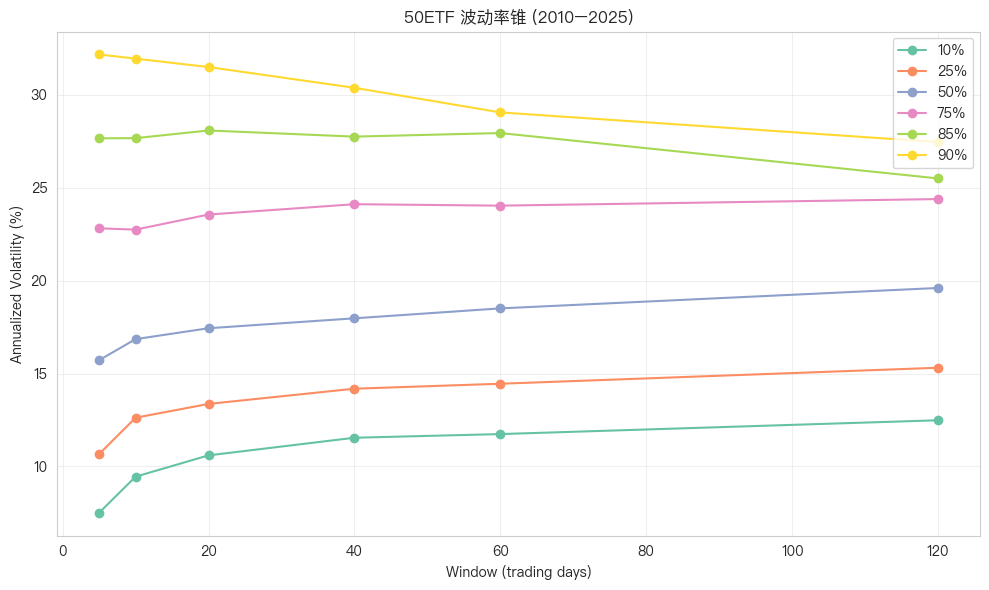

窗口=  5日: 中位数=15.7%, 85分位=27.7%, 90分位=32.2%
窗口= 10日: 中位数=16.9%, 85分位=27.7%, 90分位=32.0%
窗口= 20日: 中位数=17.4%, 85分位=28.1%, 90分位=31.5%
窗口= 40日: 中位数=18.0%, 85分位=27.8%, 90分位=30.4%
窗口= 60日: 中位数=18.5%, 85分位=28.0%, 90分位=29.1%
窗口=120日: 中位数=19.6%, 85分位=25.5%, 90分位=27.5%


In [15]:
# 构建全周期波动率锥 (2010–2025)
from src.utils.visualize import plot_vol_cone

cone = build_vol_cone(etf_full)
print('50ETF 波动率锥 (2010–2025 全周期):')
print((cone * 100).round(2).to_string())

fig = plot_vol_cone(cone, title='50ETF 波动率锥 (2010–2025)')
plt.savefig(SAVE_DIR + '01_vol_cone.png', dpi=150, bbox_inches='tight')
plt.show()

for w in [5, 10, 20, 40, 60, 120]:
    print(f'窗口={w:3d}日: 中位数={cone.loc[w, 50]*100:.1f}%, '
          f'85分位={cone.loc[w, 85]*100:.1f}%, '
          f'90分位={cone.loc[w, 90]*100:.1f}%')

## 4. 关键统计汇总

In [16]:
# 汇总统计表
summary_data = {
    '指标': [
        'ETF 日线起始', 'ETF 日线终止', 'ETF 交易日数',
        'ETF 年均波动率', 'ETF 年化收益率',
        'Call 合约总数', 'Put 合约总数', '期权总日线记录',
        '到期月份数', '执行价格档位数',
        'Call IV 均值', 'Call IV 中位数', 'Call IV 标准差',
        'Put IV 均值', 'Put IV 中位数', 'Put IV 标准差',
        '20日 HV 85分位', '20日 HV 50分位',
    ],
    '数值': [
        f'{etf_full.index.min().date()}',
        f'{etf_full.index.max().date()}',
        f'{len(etf_full):,}',
        f'{etf_full["log_return"].std() * np.sqrt(252) * 100:.2f}%',
        f'{((etf_full["close"].iloc[-1]/etf_full["close"].iloc[0])**(1/15.9)-1)*100:.1f}%',
        f'{opts_c["code"].nunique():,}',
        f'{opts_p["code"].nunique():,}',
        f'{len(all_opts):,}',
        f'{opts_c["EXPIRY_DATE"].nunique()}',
        f'{opts_c["EXERCISE_PRICE"].nunique()}',
        f'{opts_c["iv"].mean()*100:.2f}%',
        f'{opts_c["iv"].median()*100:.2f}%',
        f'{opts_c["iv"].std()*100:.2f}%',
        f'{opts_p["iv"].mean()*100:.2f}%',
        f'{opts_p["iv"].median()*100:.2f}%',
        f'{opts_p["iv"].std()*100:.2f}%',
        f'{cone.loc[20, 85]*100:.1f}%',
        f'{cone.loc[20, 50]*100:.1f}%',
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
summary_df.to_csv(SAVE_DIR + '01_summary_stats.csv', index=False, encoding='utf-8-sig')

         指标         数值
   ETF 日线起始 2010-01-04
   ETF 日线终止 2025-12-31
   ETF 交易日数      3,885
  ETF 年均波动率     22.10%
  ETF 年化收益率       1.3%
  Call 合约总数      3,400
   Put 合约总数      3,403
    期权总日线记录    455,951
      到期月份数        134
    执行价格档位数        246
 Call IV 均值     13.25%
Call IV 中位数     13.73%
Call IV 标准差     15.40%
  Put IV 均值     75.63%
 Put IV 中位数     27.92%
 Put IV 标准差    100.70%
20日 HV 85分位      28.1%
20日 HV 50分位      17.4%
